In [1]:
#enseble---------------->in decision tree we take one tree or one module this predication is called weak learning/prediction but in 
#--->Random forest the mutiple sample/tree or module we are comparing after comparing we are taking majority
#--->major voting value is cosider



#bootstrap sampling----->in the orignal data the random rows are picked that random rows are trained data after picking 
                        #random row we crtea the new dataset this new dataset is called bootstrap sampling 
#in the new data set the replcaement data(there the duplicted is accpeted) is also

In [2]:
#there are three rows     
                                 #ORIGINAL DATA
                        # |customer | Income  |loan approved 
                        # c1         5000        No
                        # c2         5500        No
                        # c3         6000        Yes
                        # c4         6500        Yes
                        # c5         7000        Yes
                        # c6         7500        Yes
#first data------->origial data
                   # c1 c2 c3 c4 c5 c6 
#sample data------># c1 c2 c3 c3 c5 c6    it will replace c4 with c3       #TREE1 ---->there are 2 No and 4 Yes


#second data------>origial data
                   # c1 c2 c3 c4 c5 c6 
#sample data------># c1 c2 c2 c4 c5 c6     it will replace c3 with c2      #TREE2---->there are 3 No and  3 Yes


#third data------>origial data
                   # c1 c2 c3 c4 c5 c6 
#sample data------># c1 c2 c3 c4 c5 c5     it will replace c6 with c5      #TREE3---->There are 2 No and 4 YEs

#It will pick randam element and replce it randomly 

In [3]:
#Bagging------>we are preforming aggregating how many Yes/NO element is present and we are counting it 

#TREE1 ---->there are 2 No and 4 Yes
#TREE2---->there are 3 No and  3 Yes
#TREE3---->There are 2 No and 4 YEs

#Tree1---> Yes
#Tree2---> No
#Tree3---> Yes

#Yes--->2
#No---->1

#final output is YES


#this is nothing but bagging 
#Bagging-----> bothstrap + aggregating 

In [5]:
#OOB--->Out of Bag

#in first three the c4 is missing------>the c4 is oob
#in second tree the c3 is missing------>the c3 is oob
#in third tree the c5  is missing------>the c5 is oob

#this is called out of bag(OOB)

#with the help of boolean we used this 
#the OOB parameter we used OOB = True

Importing the library 

In [16]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report , accuracy_score
from sklearn.tree import plot_tree

In [17]:
df = pd.read_csv(r"data\student_placement_data.csv")

In [19]:
df.head()

,Age,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Placement
0,21,1,55,40,2,No
1,24,2,60,45,3,No
2,27,2,62,48,3,No
3,30,3,65,52,4,No
4,33,4,70,58,5,Yes


In [29]:
df.columns

Index(['Age', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Assignments_Completed', 'Placement'],
      dtype='object')

In [30]:
x = df.drop("Placement",axis=1)
y = df["Placement"]

In [22]:
x_train , x_test ,y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state =42)

In [32]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state = 42)

In [71]:
from sklearn.ensemble import BaggingClassifier

model = BaggingClassifier(estimator = tree,
                        n_estimators = 3,
                         random_state = 42,
                         oob_score = True)

#for calculating out_of_bag_score we using this parameter  oob_socre = True

In [72]:
model.fit(x_train , y_train)

C:\Users\Prajwal\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:917: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
C:\Users\Prajwal\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:923: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,3
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [76]:
print(model.oob_score)

print(model.oob_score_)

print("OBB score",model.oob_score_*100)

True
0.9166666666666666
OBB score 91.66666666666666


In [77]:
from sklearn.metrics import classification_report , accuracy_score
ac = accuracy_score(y_test , prediction)
cr = classification_report(y_test , prediction,zero_division=0)
print("Classification_Report\n" ,cr)
print("Accuracy_Score" , ac)

Classification_Report
               precision    recall  f1-score   support

          No       0.00      0.00      0.00         0
         Yes       1.00      0.83      0.91         6

    accuracy                           0.83         6
   macro avg       0.50      0.42      0.45         6
weighted avg       1.00      0.83      0.91         6

Accuracy_Score 0.8333333333333334


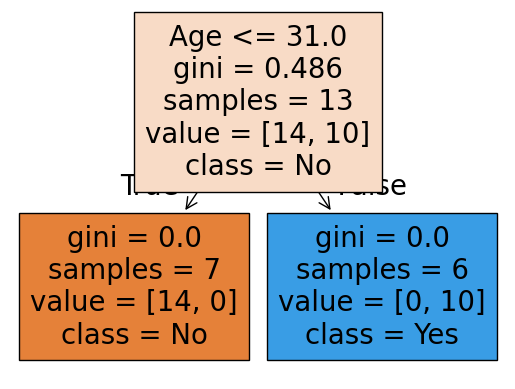

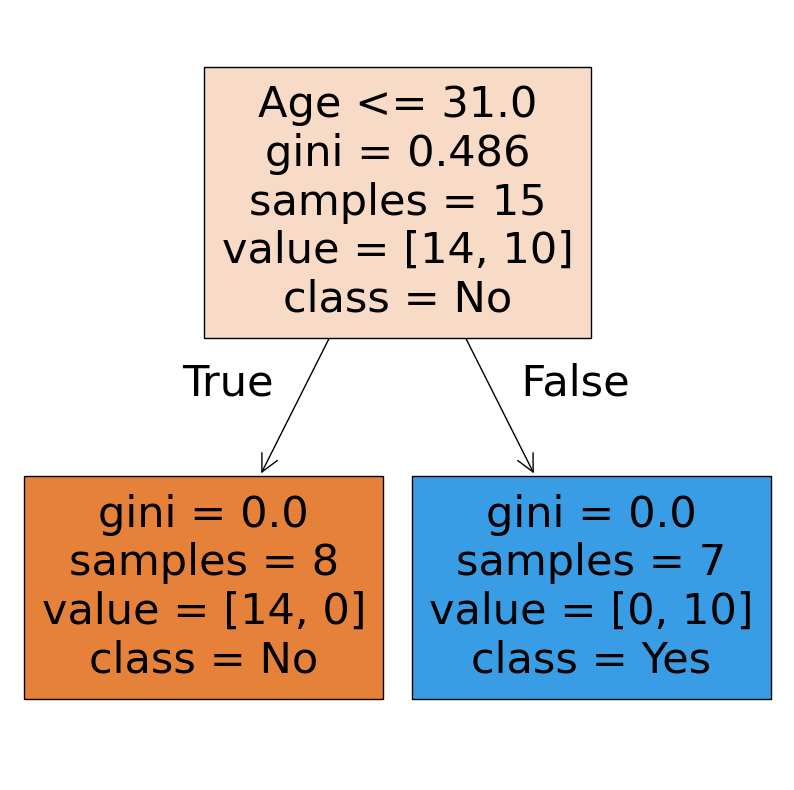

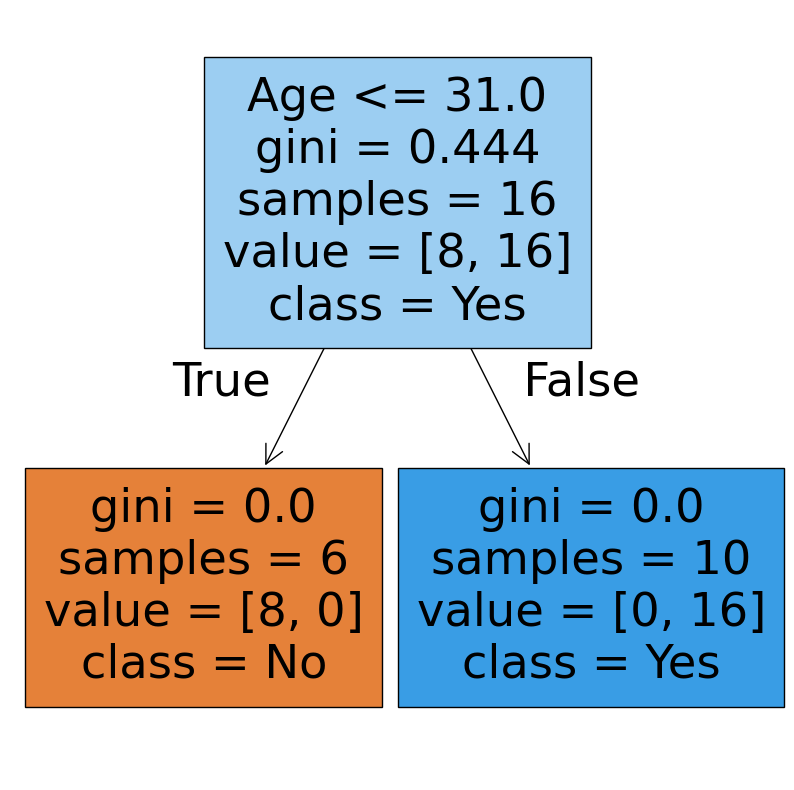

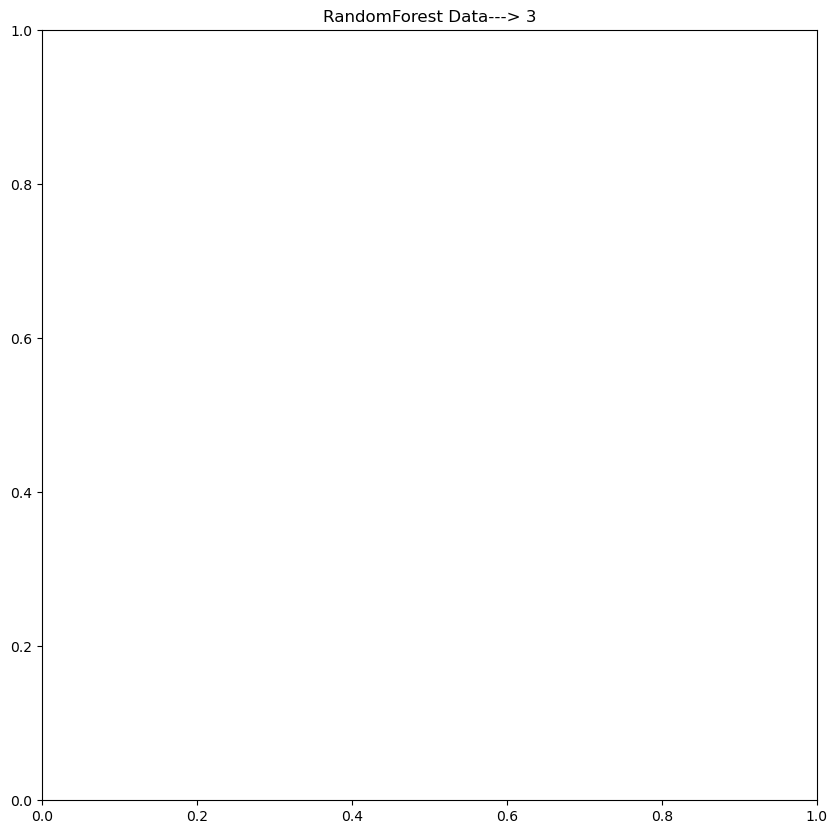

In [79]:
from sklearn.tree import plot_tree
for i,j in enumerate(model.estimators_):
    plot_tree(j,feature_names = x.columns , 
              class_names = model.classes_,filled = True)
    plt.figure(figsize=(10, 10))

plt.title(f"RandomForest Data---> {i+1}")

plt.show()